# Step 7: Comparison and checks

How much does the AMOC weaken, and does it recover, for each hosing strength under the two surface boundary conditions? Does the salt budget of every hosing run add up? And how do the results connect to Stommel's box model from project 14?

The AMOC numbers come from the CSV files saved by notebooks 04, 05 and 06. The salt check reads the runs' yearly global statistics and surface fluxes.

I load the libraries and shared functions, and set the paths and constants.

In [1]:
%matplotlib inline

import os
import sys
import glob

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")   # amoc_tools.py lives in the project's src/ folder
from amoc_tools import read_grid, output_iterations, annual_field, STEPS_PER_YEAR, SV

RUNS = os.path.expanduser("~/mitgcm_runs/hosing")
DATA_DIR = "../data"
FIG_DIR = "../figures"
HOSING = {"010": 0.1, "030": 0.3, "050": 0.5}
HOSING_END = 2200
AVERAGE_YEARS = 10
RECOVERED_WITHIN = 1.0          # within 1 Sv of the control counts as recovered (as in notebook 06)
RHO_CONST = 1035.0              # rhoConst in the data file (kg/m^3); SRELAX in g/m^2/s = (g/kg) x (m/s) x rhoConst
RHO_FRESH = 1000.0              # rhoConstFresh (kg/m^3): the hosing files are fresh-water volume fluxes at this density
SECONDS_PER_YEAR = STEPS_PER_YEAR * 86400.0
COLORS = {"restore": "tab:blue", "mixed": "tab:red"}

## Part 1: summary of the AMOC response

I read the AMOC series of both sets and compute, for each run, the change from its own control at the end of hosing (2191-2200) and at the end of recovery (2491-2500). For the 0.5 Sv mixed-BC run, which is only valid until 2089 (notebook 06), I use its last valid value instead and mark it.

In [2]:
tables = {}
for label in ["restore", "mixed"]:
    tables[label] = np.genfromtxt(os.path.join(DATA_DIR, f"amoc_index_{label}.csv"), delimiter=",", names=True)
years = tables["restore"]["model_year"]

def window_mean(series, last_year):
    keep = (years > last_year - AVERAGE_YEARS) & (years <= last_year)
    return np.mean(series[keep])

summary = []
for label in ["restore", "mixed"]:
    t = tables[label]
    c_end_hosing = window_mean(t["control_sv"], HOSING_END)
    c_end = window_mean(t["control_sv"], years[-1])
    for code, strength in HOSING.items():
        s = t[f"hose{code}_sv"]
        valid = np.isfinite(s)
        if np.all(valid):
            d_hosing = window_mean(s, HOSING_END) - c_end_hosing
            d_end = window_mean(s, years[-1]) - c_end
            note = "recovered" if abs(d_end) <= RECOVERED_WITHIN else "not recovered"
        else:
            last = years[valid][-1]
            d_hosing = s[valid][-1] - t["control_sv"][valid][-1]
            d_end = np.nan
            note = f"numerical failure after {last:.0f}; change shown is for {last:.0f}"
        summary.append((label, strength, c_end_hosing, d_hosing, 100 * d_hosing / c_end_hosing, d_end, note))

print(f"{'boundary condition':18s} {'hosing':>7s} {'control (Sv)':>12s} {'change at end of hosing':>24s} {'change at end of recovery':>26s}  result")
for row in summary:
    end_text = "n/a" if np.isnan(row[5]) else f"{row[5]:+.2f} Sv"
    print(f"{row[0]:18s} {row[1]:5.1f} Sv {row[2]:12.2f} {row[3]:+13.2f} Sv ({row[4]:+6.1f}%) {end_text:>26s}  {row[6]}")

with open(os.path.join(DATA_DIR, "summary_table.csv"), "w") as f:
    f.write("boundary_condition,hosing_sv,control_end_of_hosing_sv,change_end_of_hosing_sv,change_end_of_hosing_percent,change_end_of_recovery_sv,note\n")
    for row in summary:
        f.write(f"{row[0]},{row[1]},{row[2]:.2f},{row[3]:.2f},{row[4]:.1f},{row[5]:.2f},{row[6]}\n")
print("saved", os.path.join(DATA_DIR, "summary_table.csv"))

boundary condition  hosing control (Sv)  change at end of hosing  change at end of recovery  result
restore              0.1 Sv        19.87         -2.27 Sv ( -11.4%)                   +0.04 Sv  recovered
restore              0.3 Sv        19.87         -5.60 Sv ( -28.2%)                   +0.11 Sv  recovered
restore              0.5 Sv        19.87         -8.17 Sv ( -41.1%)                   +0.20 Sv  recovered
mixed                0.1 Sv        19.66        -19.70 Sv (-100.2%)                  -19.73 Sv  not recovered
mixed                0.3 Sv        19.66        -19.80 Sv (-100.7%)                  -19.76 Sv  not recovered
mixed                0.5 Sv        19.66        -19.78 Sv (-100.6%)                        n/a  numerical failure after 2089; change shown is for 2089
saved ../data/summary_table.csv


The summary figure shows the change in the AMOC against hosing strength, at the end of hosing (left) and at the end of recovery (right). The open marker is the 0.5 Sv mixed-BC run at its last valid year (2089).

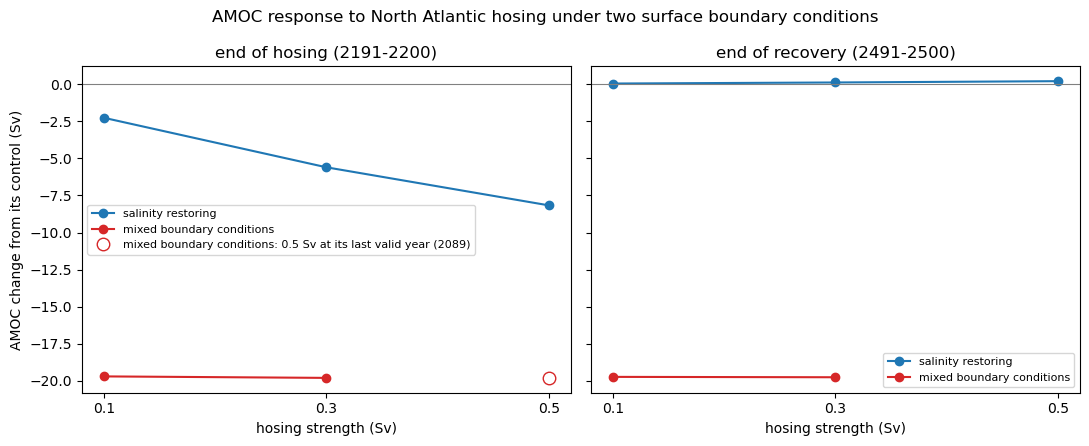

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for label, name in [("restore", "salinity restoring"), ("mixed", "mixed boundary conditions")]:
    rows = [r for r in summary if r[0] == label]
    x = np.array([r[1] for r in rows])
    d_h = np.array([r[3] for r in rows])
    d_r = np.array([r[5] for r in rows])
    complete = ~np.isnan(d_r)
    axes[0].plot(x[complete], d_h[complete], "o-", color=COLORS[label], label=name)
    if not np.all(complete):
        axes[0].plot(x[~complete], d_h[~complete], "o", mfc="none", color=COLORS[label], ms=9,
                     label=f"{name}: 0.5 Sv at its last valid year (2089)")
    axes[1].plot(x[complete], d_r[complete], "o-", color=COLORS[label], label=name)
for ax, title in zip(axes, ["end of hosing (2191-2200)", "end of recovery (2491-2500)"]):
    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_xlabel("hosing strength (Sv)")
    ax.set_title(title)
    ax.set_xticks([0.1, 0.3, 0.5])
    ax.legend(fontsize=8)
axes[0].set_ylabel("AMOC change from its control (Sv)")
fig.suptitle("AMOC response to North Atlantic hosing under two surface boundary conditions")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_summary.png"), dpi=150)
plt.show()

## Part 2: the salt check

In step 4 I found that in this model the total salt only responds to the net freshwater the ocean gains or loses, and step 5 confirmed it to within 2%. If that is right, the change in global mean salinity in a hosing run (hosing run minus its control) should be the sum of two parts:

- Dilution by the hosing water: -S x H x (1000 / 1035) x t / V, where H is the hosing (m^3/s of fresh water at 1000 kg/m^3), t the time it has been on, V the ocean volume and S the surface salinity. I use the global area-mean surface salinity of the run, because the freshwater raises sea level everywhere, and the salt carried by the surface vertical velocity is at the local surface salinity. The factor 1000/1035 is there because the model turns the freshwater mass flux into volume with `rhoConst` = 1035 kg/m^3 (`mass2rUnit = 1/rhoConst` in `ini_parms.F`). My first version left it out and came out 3.4% too large in every run. I keep that version as a separate column below.
- Salt added by the extra restoring (restoring runs only): the time integral of the global SRELAX difference, divided by (rhoConst x V).

The yearly statistics are annual averages, so I compare them with the prediction at the middle of each year.

In [4]:
grid = read_grid(os.path.join(RUNS, "spinup"), DATA_DIR)
volume = np.sum(grid["hfacc"] * grid["drf"][:, None, None] * grid["rac"][None, :, :])
area = grid["rac"] * grid["ocean"]
print(f"ocean volume {volume:.4e} m^3, ocean area {area.sum():.4e} m^2")

def global_mean_salinity(run_dirs):
    """Yearly volume-mean salinity (level 0 of the statistics file), joined over run parts."""
    values = []
    for run_dir in run_dirs:
        path = glob.glob(os.path.join(run_dir, "ts_global_stats.*.txt"))[0]
        current = None
        for line in open(path):
            if line.startswith(" field :"):
                current = line.split()[2]
            elif current == "SALT" and line.strip().startswith("0 "):
                values.append(float(line.split()[1]))
    return np.array(values)

def yearly_surface_salinity_and_srelax(run_dirs):
    """Global area-mean surface salinity (g/kg) and global SRELAX integral (g/s), one value per year."""
    sss = []
    srelax = []
    for run_dir in run_dirs:
        for it in output_iterations(run_dir, "surf_ts_annual"):
            s = annual_field(run_dir, "surf_ts_annual", "SALT", it)
            sss.append(np.sum(s * area) / area.sum())
            srelax.append(np.sum(annual_field(run_dir, "surf_flux_annual", "SRELAX", it) * area))
    return np.array(sss), np.array(srelax)

ocean volume 1.3227e+18 m^3, ocean area 3.4506e+14 m^2


This cell computes the measured and predicted salinity change for every hosing run. It takes a few minutes, because it reads every annual surface field.

In [5]:
salt_check = {}
for label in ["restore", "mixed"]:
    control_dir = [os.path.join(RUNS, f"{label}_control")]
    s_control = global_mean_salinity(control_dir)
    _, srelax_control = yearly_surface_salinity_and_srelax(control_dir)
    for code, strength in HOSING.items():
        dirs = [os.path.join(RUNS, f"{label}_hose{code}_on"), os.path.join(RUNS, f"{label}_hose{code}_off")]
        measured = global_mean_salinity(dirs) - s_control
        sss, srelax = yearly_surface_salinity_and_srelax(dirs)
        hosing_on = np.where(years <= HOSING_END, strength * SV, 0.0)                     # m^3/s each year
        dilution_per_year = -sss * hosing_on * (RHO_FRESH / RHO_CONST) * SECONDS_PER_YEAR / volume   # g/kg per year
        naive_dilution_per_year = -sss * hosing_on * SECONDS_PER_YEAR / volume            # first version, without 1000/1035
        restoring_per_year = (srelax - srelax_control) * SECONDS_PER_YEAR / (RHO_CONST * volume)
        per_year = dilution_per_year + restoring_per_year
        predicted = np.cumsum(per_year) - 0.5 * per_year                                  # value at mid-year
        naive_per_year = naive_dilution_per_year + restoring_per_year
        naive = np.cumsum(naive_per_year) - 0.5 * naive_per_year
        salt_check[(label, code)] = (measured, predicted, naive)

print(f"{'run':16s} {'year':>5s} {'measured':>10s} {'predicted':>10s} {'difference':>19s} {'first version':>14s}")
for (label, code), (measured, predicted, naive) in salt_check.items():
    for year in [2100, 2200, 2500]:
        n = int(np.where(years == year)[0][0])
        if not np.isfinite(measured[n]):
            continue
        diff = measured[n] - predicted[n]
        print(f"{label + ' ' + str(HOSING[code]) + ' Sv':16s} {year:5d} {measured[n]:+10.5f} {predicted[n]:+10.5f} "
              f"{diff:+11.5f} ({100 * diff / predicted[n]:+5.1f}%) {naive[n]:+12.5f}")

run               year   measured  predicted          difference  first version
restore 0.1 Sv    2100   -0.00197   -0.00196    -0.00000 ( +0.1%)     -0.00224
restore 0.1 Sv    2200   -0.00487   -0.00486    -0.00000 ( +0.0%)     -0.00542
restore 0.1 Sv    2500   -0.00531   -0.00530    -0.00000 ( +0.0%)     -0.00586
restore 0.3 Sv    2100   -0.00507   -0.00506    -0.00000 ( +0.0%)     -0.00589
restore 0.3 Sv    2200   -0.01288   -0.01288    -0.00001 ( +0.0%)     -0.01454
restore 0.3 Sv    2500   -0.01364   -0.01363    -0.00001 ( +0.0%)     -0.01529
restore 0.5 Sv    2100   -0.00602   -0.00603    +0.00000 ( -0.0%)     -0.00740
restore 0.5 Sv    2200   -0.01647   -0.01646    -0.00000 ( +0.0%)     -0.01922
restore 0.5 Sv    2500   -0.01829   -0.01828    -0.00001 ( +0.0%)     -0.02105
mixed 0.1 Sv      2100   -0.00786   -0.00786    -0.00000 ( +0.0%)     -0.00814
mixed 0.1 Sv      2200   -0.01574   -0.01573    -0.00000 ( +0.0%)     -0.01628
mixed 0.1 Sv      2500   -0.01578   -0.01577    -0.

This figure shows measured (solid) and predicted (dashed) salinity change for every run. The restoring runs (left) lose much less salt than dilution alone would predict, because the restoring puts most of it back. The mixed-BC runs (right) follow pure dilution.

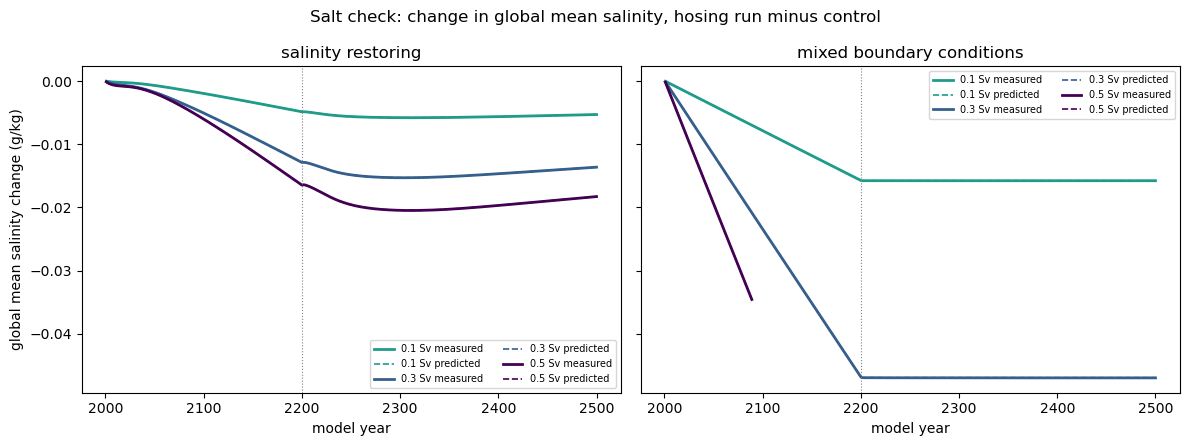

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
shades = {"010": 0.45, "030": 0.7, "050": 1.0}
for ax, label, name in [(axes[0], "restore", "salinity restoring"), (axes[1], "mixed", "mixed boundary conditions")]:
    for code, strength in HOSING.items():
        measured, predicted, _ = salt_check[(label, code)]
        color = plt.cm.viridis(1 - shades[code])
        ax.plot(years, measured, color=color, lw=2, label=f"{strength} Sv measured")
        ax.plot(years, predicted, color=color, lw=1.2, ls="--", label=f"{strength} Sv predicted")
    ax.axvline(HOSING_END, color="0.5", ls=":", lw=0.8)
    ax.set_xlabel("model year")
    ax.set_title(name)
    ax.legend(fontsize=7, ncol=2)
axes[0].set_ylabel("global mean salinity change (g/kg)")
fig.suptitle("Salt check: change in global mean salinity, hosing run minus control")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_salt_check.png"), dpi=150)
plt.show()

## Part 3: what plays the role of Stommel's delta?

In Stommel's model, delta compares how fast salinity is pulled back to its forcing value with how fast temperature is. I compute the same ratio for the two boundary conditions from the restoring time scales in the `data` files.

In [7]:
tau_theta = 5184000.0        # tauThetaClimRelax (s), 60 days, in both boundary conditions
tau_salt_restore = 15552000.0  # tauSaltClimRelax (s), 180 days, restoring runs only
print(f"restoring runs: delta = tau_theta / tau_salt = {tau_theta / tau_salt_restore:.3f} "
      f"(salinity pulled back 3 times more slowly than temperature)")
print("mixed BC:       delta = 0 (tauSaltClimRelax = 0 switches salinity restoring off; nothing pulls salinity back)")
top_layer = grid["drf"][0]
print(f"restoring 'piston velocity' for salinity: {top_layer:.0f} m / 180 days = {top_layer / tau_salt_restore * SECONDS_PER_YEAR:.0f} m per year")

restoring runs: delta = tau_theta / tau_salt = 0.333 (salinity pulled back 3 times more slowly than temperature)
mixed BC:       delta = 0 (tauSaltClimRelax = 0 switches salinity restoring off; nothing pulls salinity back)
restoring 'piston velocity' for salinity: 50 m / 180 days = 100 m per year
